# Lasso Regression Demo: Projected GD, Randomized Coordinate Descent, Proximal GD, and Stochastic Proximal GD

In this notebook, we solve the sparse linear regression problem from four first-order viewpoints in the same order as the slides:

1. **Projected gradient descent (PGD)** for the **constrained** Lasso form
2. **Randomized coordinate descent (RCD)** for the **penalized** Lasso form
3. **Proximal gradient descent (Prox-GD)** for the **penalized** Lasso form
4. **Stochastic proximal gradient descent** for the **penalized** Lasso form

We consider the two standard formulations:

$$
\text{Penalized Lasso:}\qquad
\min_{\theta \in \mathbb{R}^d}
\frac{1}{2n}\|y - X\theta\|_2^2 + \lambda \|\theta\|_1,
$$

and

$$
\text{Constrained Lasso:}\qquad
\min_{\theta \in \mathbb{R}^d}
\frac{1}{2n}\|y - X\theta\|_2^2
\quad\text{s.t.}\quad
\|\theta\|_1 \le \tau.
$$

To compare them on the same dataset, we will:
- solve the penalized Lasso with randomized coordinate descent / Prox-GD / stochastic proximal GD,
- compute a matched radius
  $$
  \tau = \|\hat\theta_{\mathrm{sk}}\|_1,
  $$
  from a high-accuracy penalized Lasso solution,
- and then run projected GD on the corresponding constrained problem.

The stopping rules are also aligned with the slides:
- **PGD / Prox-GD:** stop when $\|\theta_{t+1} - \theta_t\|_2 < \texttt{tol}$;
- **Randomized coordinate descent:** every $d$ coordinate updates, stop if the largest coordinate change in the last $d$ updates is smaller than $\texttt{tol}$;
- **Stochastic proximal GD:** after each epoch, stop when the epoch-to-epoch parameter change is smaller than $\texttt{tol}$.


In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

np.random.seed(42)
np.set_printoptions(precision=6, suppress=True)

## 1. Generate synthetic sparse regression data

We generate data from

$$
y = X\theta^\star + \varepsilon,
$$

where only a few entries of $\theta^\star$ are nonzero.


In [33]:
n = 120
d = 40

X = np.random.randn(n, d)

theta_true = np.zeros(d)
theta_true[[1, 7, 12, 20, 31]] = np.array([2.5, -1.8, 1.2, -2.2, 1.5])

noise = 0.8 * np.random.randn(n)
y = X @ theta_true + noise

print("n =", n, ", d =", d)
print("true support =", np.where(theta_true != 0)[0])

n = 120 , d = 40
true support = [ 1  7 12 20 31]


## 2. Visualize the true sparse theta vector

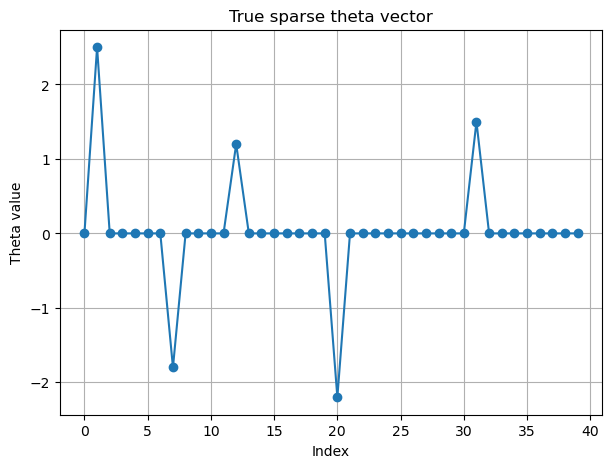

In [34]:
plt.figure(figsize=(7, 5))
plt.plot(theta_true, marker="o")
plt.xlabel("Index")
plt.ylabel("Theta value")
plt.title("True sparse theta vector")
plt.grid(True)
plt.show()

## 3. Common utilities

We standardize the design matrix and center the response so that the optimization routines are easier to compare.


In [35]:
def standardize_design(X, y):
    '''
    Standardize the columns of X and center y.
    '''
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)

    X_mean = X.mean(axis=0)
    X_std = X.std(axis=0, ddof=0)
    X_std[X_std == 0.0] = 1.0

    y_mean = y.mean()

    X_scaled = (X - X_mean) / X_std
    y_centered = y - y_mean

    stats = {
        "X_mean": X_mean,
        "X_std": X_std,
        "y_mean": y_mean,
    }
    return X_scaled, y_centered, stats


def recover_original_scale(theta_scaled, stats):
    '''
    Convert thetas in the standardized problem back to the original scale.
    '''
    theta_scaled = np.asarray(theta_scaled, dtype=float).reshape(-1)
    theta_orig = theta_scaled / stats["X_std"]
    intercept = stats["y_mean"] - stats["X_mean"] @ theta_orig
    return intercept, theta_orig


def predict_from_standardized_fit(X, theta_scaled, stats):
    '''
    Predict on the original X using a theta vector fitted on standardized data.
    '''
    intercept, theta_orig = recover_original_scale(theta_scaled, stats)
    return intercept + X @ theta_orig


def lasso_objective(X, y, theta, lam):
    '''
    Penalized Lasso objective:
        1/(2n) ||y - X theta||^2 + lam * ||theta||_1
    '''
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)
    theta = np.asarray(theta, dtype=float).reshape(-1)

    n = X.shape[0]
    resid = y - X @ theta
    return 0.5 / n * np.dot(resid, resid) + lam * np.linalg.norm(theta, ord=1)


def constrained_lasso_objective(X, y, theta):
    '''
    Smooth part only:
        1/(2n) ||y - X theta||^2
    for the constrained formulation.
    '''
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)
    theta = np.asarray(theta, dtype=float).reshape(-1)

    n = X.shape[0]
    resid = y - X @ theta
    return 0.5 / n * np.dot(resid, resid)


def soft_threshold(x, t):
    '''
    Soft-thresholding operator.
    '''
    x = np.asarray(x, dtype=float)
    return np.sign(x) * np.maximum(np.abs(x) - t, 0.0)


def lasso_gradient(X, y, theta):
    '''
    Gradient of the smooth part
        g(theta) = 1/(2n) ||y - X theta||^2.
    '''
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)
    theta = np.asarray(theta, dtype=float).reshape(-1)

    n = X.shape[0]
    return (X.T @ (X @ theta - y)) / n


def estimate_lipschitz_constant(X):
    '''
    Lipschitz constant of grad g(theta) = (1/n) X^T (X theta - y):
        L = lambda_max(X^T X / n).
    '''
    X = np.asarray(X, dtype=float)
    n = X.shape[0]
    smax = np.linalg.norm(X, ord=2)
    return (smax ** 2) / n


X_scaled, y_centered, stats = standardize_design(X, y)
L = estimate_lipschitz_constant(X_scaled)

print("Estimated Lipschitz constant L =", L)

Estimated Lipschitz constant L = 2.1940119322682845


## 4. Projected gradient descent for constrained Lasso

Projected GD applies directly to

$$
\min_\theta \frac{1}{2n}\|y - X\theta\|_2^2
\quad\text{s.t.}\quad
\|\theta\|_1 \le \tau.
$$

The update has the form

$$
\eta_{t+1}
=
\theta_t - \gamma \nabla g(\theta_t),
\qquad
\theta_{t+1}
=
\Pi_{\|\cdot\|_1 \le \tau}(\eta_{t+1}),
$$

where

$$
g(\theta)=\frac{1}{2n}\|y-X\theta\|_2^2.
$$

In the implementation below, the stopping rule is

$$
\|\theta_{t+1}-\theta_t\|_2 < \texttt{tol}.
$$


In [36]:
def project_onto_l1_ball(v, tau):
    '''
    Euclidean projection onto the l1-ball {theta : ||theta||_1 <= tau}.
    '''
    v = np.asarray(v, dtype=float).reshape(-1)

    if tau < 0:
        raise ValueError("tau must be nonnegative.")

    if np.linalg.norm(v, ord=1) <= tau:
        return v.copy()

    u = np.sort(np.abs(v))[::-1]
    cssv = np.cumsum(u)
    rho_candidates = u - (cssv - tau) / (np.arange(len(u)) + 1)
    rho = np.where(rho_candidates > 0)[0][-1]
    threshold = (cssv[rho] - tau) / (rho + 1.0)

    return np.sign(v) * np.maximum(np.abs(v) - threshold, 0.0)


def lasso_projected_gradient(X, y, tau, gamma=None, max_iter=10000, tol=1e-10):
    '''
    Solve the constrained Lasso problem
        min 1/(2n) ||y - X theta||^2
        s.t. ||theta||_1 <= tau
    by projected gradient descent.

    Stopping rule:
        stop if ||theta_{t+1} - theta_t||_2 < tol.
    '''
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)

    if gamma is None:
        L = estimate_lipschitz_constant(X)
        gamma = 1.0 / L

    d = X.shape[1]
    theta = np.zeros(d)
    loss_history = []
    stop_reason = "max_iter"

    for t in range(max_iter):
        theta_old = theta.copy()

        grad_t = lasso_gradient(X, y, theta)
        eta_t = theta - gamma * grad_t
        theta = project_onto_l1_ball(eta_t, tau)

        loss_history.append(constrained_lasso_objective(X, y, theta))

        if np.linalg.norm(theta - theta_old) < tol:
            stop_reason = "tol"
            break

    return {
        "theta": theta,
        "loss_history": np.array(loss_history),
        "gamma": gamma,
        "tau": tau,
        "n_iter": t + 1,
        "tol": tol,
        "stop_rule": "||theta_(t+1) - theta_t||_2 < tol",
        "stop_reason": stop_reason,
    }


In [37]:
lam = 0.15

# Use a matched l1 radius from a high-accuracy penalized Lasso baseline.
lasso_sk = Lasso(alpha=lam, fit_intercept=False, max_iter=100000, tol=1e-10)
lasso_sk.fit(X_scaled, y_centered)
theta_sklearn = lasso_sk.coef_
tau = np.linalg.norm(theta_sklearn, ord=1)

res_proj = lasso_projected_gradient(
    X_scaled,
    y_centered,
    tau=tau,
    gamma=None,
    max_iter=10000,
    tol=1e-10,
)

y_hat_proj = predict_from_standardized_fit(X, res_proj["theta"], stats)
y_hat_sk = predict_from_standardized_fit(X, theta_sklearn, stats)

mse_proj = mean_squared_error(y, y_hat_proj)
mse_sk = mean_squared_error(y, y_hat_sk)

print("lambda =", lam)
print("matched tau =", tau)


lambda = 0.15
matched tau = 8.811203305482588


## 5. Result: Projected gradient descent for constrained Lasso

Iterations          : 52
Step size gamma     : 0.4557860352956912
Constraint radius   : 8.811203305482588
Final objective     : 0.3402026522157983
Prediction MSE      : 0.6804053044315967
Stopping rule       : ||theta_(t+1) - theta_t||_2 < tol
Stop reason         : tol
Tolerance           : 1e-10
Estimated theta     : [ 0.        2.489809  0.       -0.       -0.       -0.       -0.
 -1.68434  -0.        0.        0.       -0.        1.14023   0.
  0.        0.        0.        0.        0.       -0.       -1.909456
  0.        0.        0.        0.        0.       -0.       -0.
  0.        0.       -0.        1.529682  0.        0.       -0.
 -0.057687  0.       -0.        0.        0.      ]


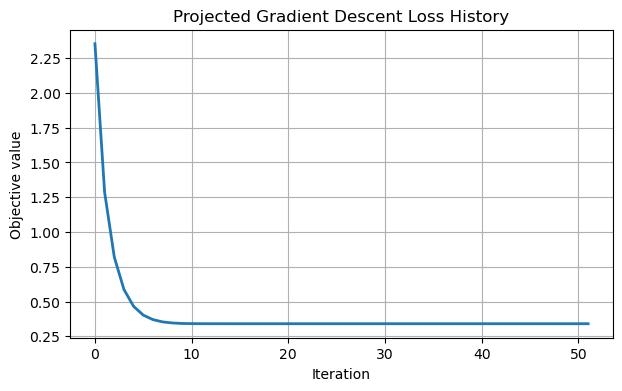

In [38]:
print("Iterations          :", res_proj["n_iter"])
print("Step size gamma     :", res_proj["gamma"])
print("Constraint radius   :", res_proj["tau"])
print("Final objective     :", res_proj["loss_history"][-1])
print("Prediction MSE      :", mse_proj)
print("Stopping rule       :", res_proj["stop_rule"])
print("Stop reason         :", res_proj["stop_reason"])
print("Tolerance           :", res_proj["tol"])
print("Estimated theta     :", res_proj["theta"])

plt.figure(figsize=(7, 4))
plt.plot(res_proj["loss_history"], linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Objective value")
plt.title("Projected Gradient Descent Loss History")
plt.grid(True)
plt.show()


## 6. Randomized coordinate descent for penalized Lasso

For

$$
\min_\theta \frac{1}{2n}\|y - X\theta\|_2^2 + \lambda \|\theta\|_1,
$$

we sample one coordinate $i_t \in [d]$ uniformly at random at iteration $t$.

After fixing all other coordinates, define

$$
r_t^{(i_t)} = y - \sum_{j\ne i_t} X_{\cdot j}(\theta_t)_j
= y - X\theta_t + X_{\cdot i_t}(\theta_t)_{i_t}.
$$

Then

$$
a_{i_t}=\frac{1}{n}\|X_{\cdot i_t}\|_2^2,
\qquad
\rho_{i_t}=\frac{1}{n}X_{\cdot i_t}^{\top} r_t^{(i_t)},
$$

and the one-dimensional Lasso subproblem has the closed-form minimizer

$$
u_t^*
=
\frac{S(\rho_{i_t},\lambda)}{a_{i_t}}.
$$

So the randomized coordinate update is

$$
(\theta_{t+1})_{i_t}=u_t^*,
\qquad
(\theta_{t+1})_j=(\theta_t)_j \quad (j\ne i_t).
$$

In the implementation below, **one iteration means one coordinate update**, and the stopping rule is checked every iteration:
stop when the absolute change of the selected coordinate is below `tol`.


In [39]:
from collections import deque
import numpy as np

def lasso_randomized_coordinate_descent(
    X,
    y,
    lam,
    max_iter=50000,
    tol=1e-10,
    random_state=0,
    stop_window=None,
):
    '''
    Solve the penalized Lasso problem
        min 1/(2n) ||y - X theta||^2 + lam ||theta||_1
    by randomized coordinate descent.

    At iteration t:
        sample i_t uniformly from [d],
        form the partial residual r_t^(i_t),
        compute a_{i_t} and rho_{i_t},
        update only coordinate i_t by the closed-form minimizer
            u_t^* = S(rho_{i_t}, lam) / a_{i_t}.

    Stopping rule:
        let
            delta_{i_t} = |(theta_{t+1})_{i_t} - (theta_t)_{i_t}|.
        Stop if the maximum selected-coordinate change over the most recent
        'stop_window' iterations is smaller than tol:
            max recent delta_{i_t} < tol.

    Notes:
        - If stop_window is None, we set stop_window = d.
        - loss_history is recorded at every iteration.
    '''
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)

    n, d = X.shape
    rng = np.random.default_rng(random_state)

    if stop_window is None:
        stop_window = d

    theta = np.zeros(d)
    r = y.copy()   # r_t = y - X theta_t
    a = np.sum(X ** 2, axis=0) / n

    loss_history = []
    recent_changes = deque(maxlen=stop_window)
    stop_reason = "max_iter"

    for t in range(max_iter):
        i_t = rng.integers(d)
        theta_old_i = theta[i_t]

        if a[i_t] == 0.0:
            u_t_star = 0.0
            theta[i_t] = 0.0
        else:
            # r_t^(i_t) = y - X theta_t + X_{. i_t} (theta_t)_{i_t}
            r = r + X[:, i_t] * theta_old_i

            rho_i_t = np.dot(X[:, i_t], r) / n
            u_t_star = soft_threshold(rho_i_t, lam) / a[i_t]

            theta[i_t] = u_t_star

            # restore r_{t+1} = y - X theta_{t+1}
            r = r - X[:, i_t] * theta[i_t]

        delta_i_t = abs(theta[i_t] - theta_old_i)
        recent_changes.append(delta_i_t)

        loss_history.append(lasso_objective(X, y, theta, lam))

        if len(recent_changes) == stop_window and max(recent_changes) < tol:
            stop_reason = "tol"
            break

    return {
        "theta": theta,
        "loss_history": np.array(loss_history),
        "n_iter": t + 1,
        "tol": tol,
        "stop_window": stop_window,
        "stop_rule": "max recent |(theta_(t+1))_(i_t) - (theta_t)_(i_t)| < tol",
        "stop_reason": stop_reason,
    }

In [40]:
res_cd = lasso_randomized_coordinate_descent(
    X_scaled,
    y_centered,
    lam=lam,
    max_iter=50000,
    tol=1e-10,
    random_state=0,
)

y_hat_cd = predict_from_standardized_fit(X, res_cd["theta"], stats)
mse_cd = mean_squared_error(y, y_hat_cd)


## 7. Result: Randomized coordinate descent for penalized Lasso

Iterations          : 663
Final objective     : 1.6618831480381866
Prediction MSE      : 0.6804053044190539
Stopping rule       : max recent |(theta_(t+1))_(i_t) - (theta_t)_(i_t)| < tol
Stop reason         : tol
Tolerance           : 1e-10
Estimated theta     : [ 0.        2.489809  0.       -0.       -0.       -0.       -0.
 -1.68434  -0.        0.        0.       -0.        1.14023   0.
  0.        0.        0.        0.        0.       -0.       -1.909456
  0.        0.        0.        0.        0.       -0.       -0.
  0.        0.       -0.        1.529682  0.        0.       -0.
 -0.057687  0.       -0.        0.        0.      ]


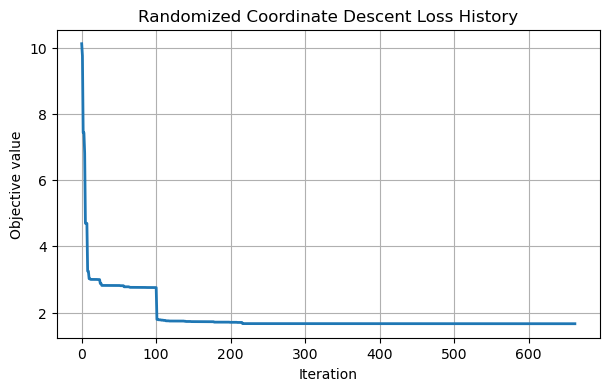

In [41]:
print("Iterations          :", res_cd["n_iter"])
print("Final objective     :", res_cd["loss_history"][-1])
print("Prediction MSE      :", mse_cd)
print("Stopping rule       :", res_cd["stop_rule"])
print("Stop reason         :", res_cd["stop_reason"])
print("Tolerance           :", res_cd["tol"])
print("Estimated theta     :", res_cd["theta"])

plt.figure(figsize=(7, 4))
plt.plot(res_cd["loss_history"], linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Objective value")
plt.title("Randomized Coordinate Descent Loss History")
plt.grid(True)
plt.show()


## 8. Proximal gradient descent for penalized Lasso

We write the penalized Lasso objective as

$$
F(\theta) = g(\theta) + h(\theta),
$$

where

$$
g(\theta) = \frac{1}{2n}\|y - X\theta\|_2^2,
\qquad
h(\theta) = \lambda \|\theta\|_1.
$$

Then the proximal gradient update is

$$
\eta_{t+1} = \theta_t - \gamma \nabla g(\theta_t),
\qquad
\theta_{t+1}=\operatorname{prox}_{\gamma h}(\eta_{t+1})
=
\operatorname{soft}(\eta_{t+1},\gamma\lambda).
$$

The stopping rule is

$$
\|\theta_{t+1}-\theta_t\|_2 < \texttt{tol}.
$$


In [42]:
def lasso_proximal_gradient(X, y, lam, gamma=None, max_iter=10000, tol=1e-10):
    '''
    Solve the penalized Lasso problem
        min g(theta) + h(theta)
    with
        g(theta) = 1/(2n) ||y - X theta||^2,
        h(theta) = lam ||theta||_1,
    by proximal gradient descent.

    Stopping rule:
        stop if ||theta_{t+1} - theta_t||_2 < tol.
    '''
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)

    if gamma is None:
        L = estimate_lipschitz_constant(X)
        gamma = 1.0 / L

    d = X.shape[1]
    theta = np.zeros(d)
    loss_history = []
    stop_reason = "max_iter"

    for t in range(max_iter):
        theta_old = theta.copy()

        grad_t = lasso_gradient(X, y, theta)
        eta_t = theta - gamma * grad_t
        theta = soft_threshold(eta_t, gamma * lam)

        loss_history.append(lasso_objective(X, y, theta, lam))

        if np.linalg.norm(theta - theta_old) < tol:
            stop_reason = "tol"
            break

    return {
        "theta": theta,
        "loss_history": np.array(loss_history),
        "gamma": gamma,
        "n_iter": t + 1,
        "tol": tol,
        "stop_rule": "||theta_(t+1) - theta_t||_2 < tol",
        "stop_reason": stop_reason,
    }


In [43]:
res_pg = lasso_proximal_gradient(
    X_scaled,
    y_centered,
    lam=lam,
    gamma=None,
    max_iter=10000,
    tol=1e-10,
)

y_hat_pg = predict_from_standardized_fit(X, res_pg["theta"], stats)
mse_pg = mean_squared_error(y, y_hat_pg)


## 9. Result: Proximal gradient descent for penalized Lasso

Iterations          : 53
Step size gamma     : 0.4557860352956912
Final objective     : 1.6618831480381866
Prediction MSE      : 0.6804053044555337
Stopping rule       : ||theta_(t+1) - theta_t||_2 < tol
Stop reason         : tol
Tolerance           : 1e-10
Estimated theta     : [ 0.        2.489809  0.       -0.       -0.       -0.       -0.
 -1.68434  -0.        0.        0.       -0.        1.14023   0.
  0.        0.        0.        0.        0.       -0.       -1.909456
  0.        0.        0.        0.        0.       -0.       -0.
  0.        0.       -0.        1.529682  0.        0.       -0.
 -0.057687  0.       -0.        0.        0.      ]


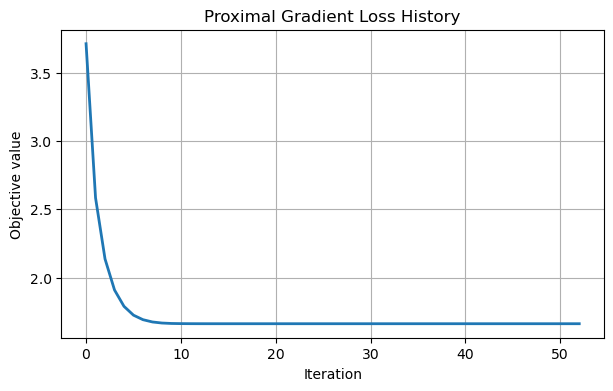

In [44]:
print("Iterations          :", res_pg["n_iter"])
print("Step size gamma     :", res_pg["gamma"])
print("Final objective     :", res_pg["loss_history"][-1])
print("Prediction MSE      :", mse_pg)
print("Stopping rule       :", res_pg["stop_rule"])
print("Stop reason         :", res_pg["stop_reason"])
print("Tolerance           :", res_pg["tol"])
print("Estimated theta     :", res_pg["theta"])

plt.figure(figsize=(7, 4))
plt.plot(res_pg["loss_history"], linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Objective value")
plt.title("Proximal Gradient Loss History")
plt.grid(True)
plt.show()


## 10. Stochastic proximal gradient descent for penalized Lasso

For the smooth part

$$
g(\theta)=\frac{1}{2n}\|y-X\theta\|_2^2,
$$

at iteration $t$ we sample one data index $i_t \in [n]$ uniformly at random and use the single-sample stochastic gradient

$$
\nabla g_{i_t}(\theta_t)
=
x_{i_t}\bigl(x_{i_t}^{\top}\theta_t-y_{i_t}\bigr).
$$

Then the stochastic proximal update is

$$
\theta_{t+1}
=
\operatorname{soft}\bigl(
\theta_t-\gamma_t \nabla g_{i_t}(\theta_t),\,
\gamma_t\lambda
\bigr),
\qquad
\gamma_t = \frac{\gamma_0}{\sqrt{1+\alpha t}}.
$$

This is the single-sample SGD-style method for Lasso.
In the implementation below, **one iteration means one sampled data point**, and the loss is recorded at every iteration.
The stopping rule is checked every iteration:
stop when $\|\theta_{t+1}-\theta_t\|_2 < \texttt{tol}$.


In [45]:
def lasso_stochastic_proximal_gradient(
    X,
    y,
    lam,
    max_iter=5000,
    gamma0=0.15,
    decay=0.05,
    tol=1e-10,
    random_state=0,
):
    '''
    Single-sample stochastic proximal gradient descent for penalized Lasso.

    At iteration t:
        sample i_t uniformly from [n],
        form grad_t = x_{i_t} (x_{i_t}^T theta_t - y_{i_t}),
        set gamma_t = gamma0 / sqrt(1 + decay * t),
        update theta_{t+1} = soft(theta_t - gamma_t grad_t, gamma_t * lam).

    Stopping rule:
        stop if ||theta_{t+1} - theta_t||_2 < tol.
    '''
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)

    rng = np.random.default_rng(random_state)
    n, d = X.shape
    theta = np.zeros(d)
    loss_history = []
    stop_reason = "max_iter"

    for t in range(max_iter):
        theta_old = theta.copy()

        i_t = rng.integers(n)
        x_i_t = X[i_t]
        y_i_t = y[i_t]

        grad_t = x_i_t * (x_i_t @ theta - y_i_t)
        gamma_t = gamma0 / np.sqrt(1.0 + decay * t)

        theta = soft_threshold(theta - gamma_t * grad_t, gamma_t * lam)
        loss_history.append(lasso_objective(X, y, theta, lam))

        if np.linalg.norm(theta - theta_old) < tol:
            stop_reason = "tol"
            break

    return {
        "theta": theta,
        "loss_history": np.array(loss_history),
        "n_iter": t + 1,
        "gamma0": gamma0,
        "decay": decay,
        "tol": tol,
        "stop_rule": "||theta_(t+1) - theta_t||_2 < tol",
        "stop_reason": stop_reason,
    }


In [46]:
res_spg = lasso_stochastic_proximal_gradient(
    X_scaled,
    y_centered,
    lam=lam,
    max_iter=5000,
    gamma0=0.15,
    decay=0.05,
    tol=1e-10,
    random_state=123,
)

y_hat_spg = predict_from_standardized_fit(X, res_spg["theta"], stats)
mse_spg = mean_squared_error(y, y_hat_spg)


## 11. Result: Stochastic proximal gradient descent for penalized Lasso

Iterations          : 5000
Initial gamma0      : 0.15
Decay               : 0.05
Final objective     : 1.7498809770255186
Prediction MSE      : 0.7522876227382737
Stopping rule       : ||theta_(t+1) - theta_t||_2 < tol
Stop reason         : max_iter
Tolerance           : 1e-10
Estimated theta     : [ 0.00479   2.41095  -0.003512 -0.021096 -0.000663 -0.012229  0.014283
 -1.756582  0.01255  -0.       -0.010033 -0.045487  1.099492  0.037309
 -0.023141 -0.010678 -0.01185   0.076759 -0.010127 -0.004847 -1.8183
  0.008381 -0.000701  0.        0.082708  0.009609 -0.042855 -0.012722
  0.023691 -0.02031   0.032989  1.458173  0.026719  0.009753 -0.019526
 -0.001846 -0.008285  0.001765  0.001575  0.011963]


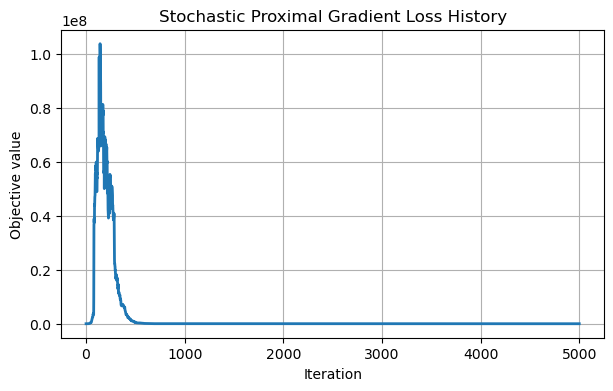

In [47]:
print("Iterations          :", res_spg["n_iter"])
print("Initial gamma0      :", res_spg["gamma0"])
print("Decay               :", res_spg["decay"])
print("Final objective     :", res_spg["loss_history"][-1])
print("Prediction MSE      :", mse_spg)
print("Stopping rule       :", res_spg["stop_rule"])
print("Stop reason         :", res_spg["stop_reason"])
print("Tolerance           :", res_spg["tol"])
print("Estimated theta     :", res_spg["theta"])

plt.figure(figsize=(7, 4))
plt.plot(res_spg["loss_history"], linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Objective value")
plt.title("Stochastic Proximal Gradient Loss History")
plt.grid(True)
plt.show()


## 12. Final comparison of estimated $\theta$

In [48]:
print("True theta                    :", theta_true)
print("Projected gradient theta      :", res_proj["theta"])
print("Randomized coordinate theta   :", res_cd["theta"])
print("Proximal gradient theta       :", res_pg["theta"])
print("Stochastic proximal GD theta  :", res_spg["theta"])
print("scikit-learn theta            :", theta_sklearn)


True theta                    : [ 0.   2.5  0.   0.   0.   0.   0.  -1.8  0.   0.   0.   0.   1.2  0.
  0.   0.   0.   0.   0.   0.  -2.2  0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   1.5  0.   0.   0.   0.   0.   0.   0.   0. ]
Projected gradient theta      : [ 0.        2.489809  0.       -0.       -0.       -0.       -0.
 -1.68434  -0.        0.        0.       -0.        1.14023   0.
  0.        0.        0.        0.        0.       -0.       -1.909456
  0.        0.        0.        0.        0.       -0.       -0.
  0.        0.       -0.        1.529682  0.        0.       -0.
 -0.057687  0.       -0.        0.        0.      ]
Randomized coordinate theta   : [ 0.        2.489809  0.       -0.       -0.       -0.       -0.
 -1.68434  -0.        0.        0.       -0.        1.14023   0.
  0.        0.        0.        0.        0.       -0.       -1.909456
  0.        0.        0.        0.        0.       -0.       -0.
  0.        0.       -0.        1.529682  0.        0

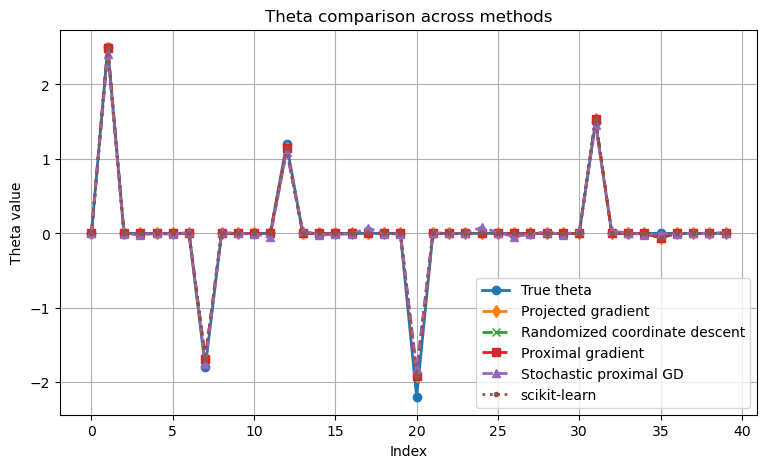

In [49]:
plt.figure(figsize=(9, 5))
plt.plot(theta_true, marker="o", linewidth=2, label="True theta")
plt.plot(res_proj["theta"], marker="d", linestyle="--", linewidth=2, label="Projected gradient")
plt.plot(res_cd["theta"], marker="x", linestyle="--", linewidth=2, label="Randomized coordinate descent")
plt.plot(res_pg["theta"], marker="s", linestyle="--", linewidth=2, label="Proximal gradient")
plt.plot(res_spg["theta"], marker="^", linestyle="--", linewidth=2, label="Stochastic proximal GD")
plt.plot(theta_sklearn, marker=".", linestyle=":", linewidth=2, label="scikit-learn")
plt.xlabel("Index")
plt.ylabel("Theta value")
plt.title("Theta comparison across methods")
plt.legend()
plt.grid(True)
plt.show()


## 14. Final result comparison

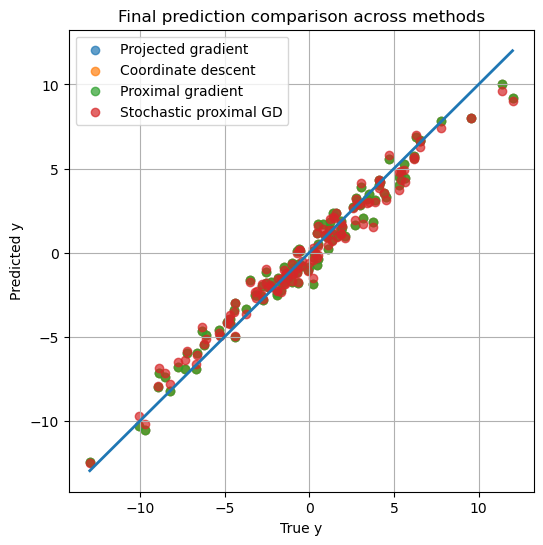

In [53]:
plt.figure(figsize=(6, 6))
plt.scatter(y, y_hat_proj, alpha=0.7, label="Projected gradient")
plt.scatter(y, y_hat_cd, alpha=0.7, label="Coordinate descent")
plt.scatter(y, y_hat_pg, alpha=0.7, label="Proximal gradient")
plt.scatter(y, y_hat_spg, alpha=0.7, label="Stochastic proximal GD")
plt.plot([y.min(), y.max()], [y.min(), y.max()], linewidth=2)
plt.xlabel("True y")
plt.ylabel("Predicted y")
plt.title("Final prediction comparison across methods")
plt.grid(True)
plt.legend()
plt.show()


## Summary

- **Projected gradient descent** solves the constrained Lasso
  $$
  \min_\theta \frac{1}{2n}\|y-X\theta\|_2^2
  \quad \text{s.t.} \quad
  \|\theta\|_1 \le \tau .
  $$
- **Randomized coordinate descent** solves the penalized Lasso by exact one-coordinate minimization via soft-thresholding.
- **Proximal gradient descent** solves the penalized Lasso by a full gradient step plus a proximal soft-threshold step.
- **Stochastic proximal gradient descent** is the single-sample SGD-style method for the penalized Lasso.
